# 💳 Transaction Risk Analysis & ML Pipeline
## Notebook 2 — SQL Feature Engineering


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('transactions_clean.csv')
conn = sqlite3.connect(':memory:')
df.to_sql('transactions', conn, index=False, if_exists='replace')
print(f'✅ Loaded {len(df):,} transactions into SQLite')

✅ Loaded 1,852,394 transactions into SQLite


## SQL Analysis 1 — Fraud by Category + State

In [2]:
query1 = '''
SELECT
    category,
    COUNT(*) AS total_txns,
    SUM(is_fraud) AS fraud_count,
    ROUND(AVG(is_fraud)*100, 3) AS fraud_rate_pct,
    ROUND(AVG(amt), 2) AS avg_amount,
    ROUND(SUM(CASE WHEN is_fraud=1 THEN amt ELSE 0 END), 2) AS total_fraud_amount
FROM transactions
GROUP BY category
ORDER BY fraud_rate_pct DESC
'''
fraud_by_cat = pd.read_sql(query1, conn)
print('Fraud Rate by Category:')
print(fraud_by_cat.to_string(index=False))

fig = px.bar(fraud_by_cat, x='category', y='fraud_rate_pct',
             title='Fraud Rate by Category (%)',
             color='fraud_rate_pct', color_continuous_scale='Reds')
fig.update_layout(template='plotly_white', xaxis_tickangle=45)
fig.show()

Fraud Rate by Category:
      category  total_txns  fraud_count  fraud_rate_pct  avg_amount  total_fraud_amount
  shopping_net      139322         2219           1.593       86.94          2214847.64
      misc_net       90654         1182           1.304       80.18           944009.71
   grocery_pos      176191         2228           1.265      116.64           695664.62
  shopping_pos      166463         1056           0.634       78.91           928132.34
 gas_transport      188029          772           0.411       63.48             9442.53
      misc_pos      114229          322           0.282       62.68            68494.84
   grocery_net       64878          175           0.270       53.69             2108.21
        travel       57956          156           0.269      111.77             1399.47
 personal_care      130085          290           0.223       48.05             7571.96
 entertainment      134118          292           0.218       64.14           147399.96
     kid

## SQL Analysis 2 — High Risk Merchants (Window Functions)

In [3]:
query2 = '''
WITH merchant_stats AS (
    SELECT
        merchant,
        category,
        COUNT(*) AS txn_count,
        SUM(is_fraud) AS fraud_count,
        ROUND(AVG(is_fraud)*100, 2) AS fraud_rate_pct,
        ROUND(AVG(amt), 2) AS avg_amount,
        ROUND(SUM(CASE WHEN is_fraud=1 THEN amt ELSE 0 END), 2) AS fraud_loss
    FROM transactions
    GROUP BY merchant, category
    HAVING txn_count >= 10
)
SELECT * FROM merchant_stats
ORDER BY fraud_rate_pct DESC
LIMIT 15
'''
high_risk_merchants = pd.read_sql(query2, conn)
print('Top 15 Highest Risk Merchants:')
print(high_risk_merchants.to_string(index=False))

Top 15 Highest Risk Merchants:
                                  merchant     category  txn_count  fraud_count  fraud_rate_pct  avg_amount  fraud_loss
                         fraud_Kozey-Boehm shopping_net       2758           60            2.18       90.63    60410.62
         fraud_Herman, Treutel and Dickens     misc_net       1870           38            2.03       85.09    30315.23
                          fraud_Terry-Huel shopping_net       2864           56            1.96       94.00    55203.84
                     fraud_Kerluke-Abshire shopping_net       2635           50            1.90       93.09    50301.53
                           fraud_Boyer PLC shopping_net       2717           51            1.88       84.12    51292.33
       fraud_Mosciski, Ziemann and Farrell shopping_net       2821           53            1.88       87.68    52948.65
       fraud_Schmeler, Bashirian and Price shopping_net       2788           52            1.87       94.03    51237.89
         

## SQL Analysis 3 — Risk Segments with CTEs

Customer Risk Segmentation:
risk_segment  customer_count  avg_txns  avg_spend  avg_late_night  avg_states
    LOW RISK             725    2358.2      69.55           457.3         1.0
 MEDIUM RISK             183     774.8      75.07           174.7         1.0
   HIGH RISK              91       9.9     606.23             2.9         1.0


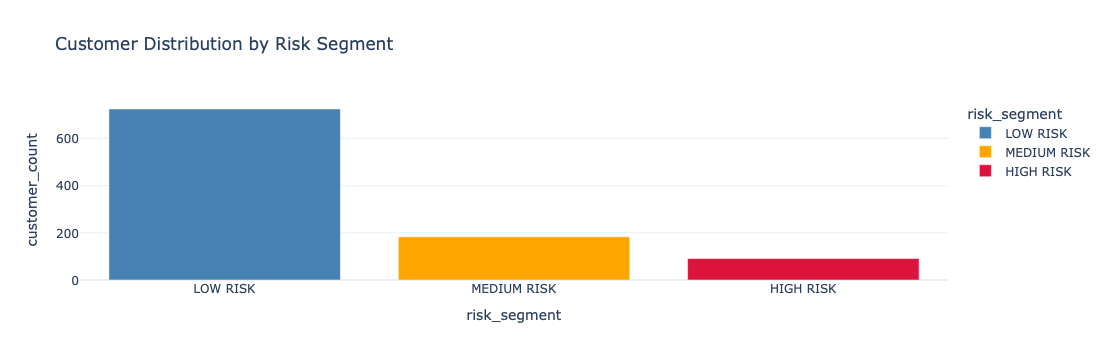

In [4]:
query3 = '''
WITH customer_stats AS (
    SELECT
        cc_num,
        COUNT(*) AS txn_count,
        ROUND(AVG(amt), 2) AS avg_amount,
        ROUND(MAX(amt), 2) AS max_amount,
        SUM(is_fraud) AS fraud_count,
        ROUND(AVG(is_fraud)*100, 2) AS fraud_rate_pct,
        SUM(CASE WHEN hour BETWEEN 0 AND 5 THEN 1 ELSE 0 END) AS late_night_txns,
        COUNT(DISTINCT category) AS unique_categories,
        COUNT(DISTINCT state) AS unique_states
    FROM transactions
    GROUP BY cc_num
),
risk_labels AS (
    SELECT *,
        CASE
            WHEN fraud_rate_pct > 5 THEN 'HIGH RISK'
            WHEN fraud_rate_pct > 1 THEN 'MEDIUM RISK'
            ELSE 'LOW RISK'
        END AS risk_segment
    FROM customer_stats
)
SELECT
    risk_segment,
    COUNT(*) AS customer_count,
    ROUND(AVG(txn_count), 1) AS avg_txns,
    ROUND(AVG(avg_amount), 2) AS avg_spend,
    ROUND(AVG(late_night_txns), 1) AS avg_late_night,
    ROUND(AVG(unique_states), 2) AS avg_states
FROM risk_labels
GROUP BY risk_segment
ORDER BY customer_count DESC
'''
risk_segments = pd.read_sql(query3, conn)
print('Customer Risk Segmentation:')
print(risk_segments.to_string(index=False))

fig = px.bar(risk_segments, x='risk_segment', y='customer_count',
             title='Customer Distribution by Risk Segment',
             color='risk_segment',
             color_discrete_map={'HIGH RISK':'crimson','MEDIUM RISK':'orange','LOW RISK':'steelblue'})
fig.update_layout(template='plotly_white')
fig.show()

## SQL Feature Engineering — All 15+ Features

In [5]:
feature_query = '''
SELECT
    t.trans_num,
    t.cc_num,
    t.amt,
    t.hour,
    t.day_of_week,
    t.month,
    t.age,
    t.category,
    t.state,
    t.is_fraud,

    -- Feature 1: Amount vs customer average
    ROUND(t.amt / NULLIF(c.avg_amount, 0), 3) AS amt_vs_customer_avg,

    -- Feature 2: Customer transaction count
    c.txn_count AS customer_txn_count,

    -- Feature 3: Unique categories used by customer
    c.unique_categories,

    -- Feature 4: Unique states transacted in
    c.unique_states,

    -- Feature 5: Late night flag
    CASE WHEN t.hour BETWEEN 0 AND 5 THEN 1 ELSE 0 END AS is_late_night,

    -- Feature 6: Weekend flag
    CASE WHEN t.day_of_week IN (5,6) THEN 1 ELSE 0 END AS is_weekend,

    -- Feature 7: High value transaction
    CASE WHEN t.amt > 500 THEN 1 ELSE 0 END AS is_high_value,

    -- Feature 8: Customer late night ratio
    ROUND(CAST(c.late_night_txns AS FLOAT) / NULLIF(c.txn_count,0), 3) AS customer_late_night_ratio,

    -- Feature 9: Amount above customer max
    CASE WHEN t.amt >= c.max_amount * 0.9 THEN 1 ELSE 0 END AS near_customer_max,

    -- Feature 10: High risk category
    CASE WHEN t.category IN ('shopping_net','grocery_pos','misc_net') THEN 1 ELSE 0 END AS is_high_risk_category,

    -- Feature 11: Senior customer flag
    CASE WHEN t.age > 60 THEN 1 ELSE 0 END AS is_senior,

    -- Feature 12: Young customer flag
    CASE WHEN t.age < 25 THEN 1 ELSE 0 END AS is_young,

    -- Feature 13: Customer max amount
    c.max_amount AS customer_max_amount,

    -- Feature 14: Customer average amount
    c.avg_amount AS customer_avg_amount,

    -- Feature 15: Multi-state customer
    CASE WHEN c.unique_states > 2 THEN 1 ELSE 0 END AS is_multi_state

FROM transactions t
LEFT JOIN (
    SELECT
        cc_num,
        COUNT(*) AS txn_count,
        AVG(amt) AS avg_amount,
        MAX(amt) AS max_amount,
        COUNT(DISTINCT category) AS unique_categories,
        COUNT(DISTINCT state) AS unique_states,
        SUM(CASE WHEN hour BETWEEN 0 AND 5 THEN 1 ELSE 0 END) AS late_night_txns
    FROM transactions
    GROUP BY cc_num
) c ON t.cc_num = c.cc_num
'''

df_features = pd.read_sql(feature_query, conn)
print(f'✅ Feature engineering complete!')
print(f'   Shape: {df_features.shape}')
print(f'   Features created: {df_features.shape[1] - 5}')
print(f'   Null values: {df_features.isnull().sum().sum()}')
df_features.head()

✅ Feature engineering complete!
   Shape: (1852394, 25)
   Features created: 20
   Null values: 0


,trans_num,cc_num,amt,hour,day_of_week,month,age,category,state,is_fraud,...,is_weekend,is_high_value,customer_late_night_ratio,near_customer_max,is_high_risk_category,is_senior,is_young,customer_max_amount,customer_avg_amount,is_multi_state
0,0b242abb623afc578575680df30655b9,2703186189652095,4.97,0,1,1,36,misc_net,NC,0,...,0,0,0.150,0,1,0,0,2181.32,89.408743,0
1,1f76529f8574734946361c461b024d99,630423337322,107.23,0,1,1,46,grocery_pos,WA,0,...,0,0,0.142,0,1,0,0,7134.75,56.078113,0
2,a1a22d70485983eac12b5b88dad1cf95,38859492057661,220.11,0,1,1,62,entertainment,ID,0,...,0,0,0.307,0,0,1,0,1219.65,69.924272,0
3,6b849c168bdad6f867558c3793159a81,3534093764340240,45.00,0,1,1,57,gas_transport,MT,0,...,0,0,0.257,0,0,0,0,6782.92,80.090040,0
4,a41d7549acf90789359a9aa5346dcb46,375534208663984,41.96,0,1,1,38,misc_pos,VA,0,...,0,0,0.226,0,0,0,0,1152.49,95.341146,0


In [6]:
# Feature correlation with fraud
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
corr = df_features[numeric_cols].corr()['is_fraud'].drop('is_fraud').abs().sort_values(ascending=False)
print('Feature correlations with is_fraud (top 10):')
print(corr.head(10).round(4).to_string())

df_features.to_csv('transactions_features.csv', index=False)
print(f'\n✅ Saved to transactions_features.csv')
print('\n➡️  Open Notebook 3 for ML Model Training')

Feature correlations with is_fraud (top 10):
is_high_value                0.3185
unique_categories            0.3033
amt                          0.2093
customer_avg_amount          0.1974
amt_vs_customer_avg          0.1874
near_customer_max            0.1503
is_high_risk_category        0.0637
customer_txn_count           0.0507
is_late_night                0.0282
customer_late_night_ratio    0.0225

✅ Saved to transactions_features.csv

➡️  Open Notebook 3 for ML Model Training
